# Exercise - Trending Skills
___
- Now that we have wrapped up covering everything that we need to know for Pandas Advanced and basically the remainder of the course
- We are going to do a quick Exercise that covers a lot of the different Methods that we just learned
    - Specifically, using the `.explode()`, `.apply()` and `.pivot_table()` in order to get a New Visualization
    - This will show the Trend of Skills throughout the Year, named: **The Top 5 Skills for Data Analysts per Month**
- For this Analysis, we will only be focussing on Data Analyst

In [3]:
# Imports
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

- After loading in all the Data as per normal with the associated Imports and Cleanup
- Create a New DataFrame called: `df_DA`
- Set it equal to our original DataFrame of `df`
    - We are then going to Filter it down for `job_title_short`'s that are equal to **Data Analyst**
    - Going to do this with the notation `df[df['job_title_short'] == "Data Analyst"]` to get all the information/rows in the DataFrame back, where the DataFrame's `job_title_short` is Data Analyst
- We don't want to alter the Original DataFrame, so for Data integrity we add the `.copy()` Method to the end of this

In [7]:
# Creating a New DataFrame and Filtering it based on the job_title_short
df_DA = df[df['job_title_short'] == "Data Analyst"].copy()

# Printing it out and inspecting the Results
df_DA

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
12,Data Analyst,Stagiaire Data Analyst (H/F) - Lyon (69006),"Lyon, France",via Jobijoba,Full-time and Internship,False,France,2023-12-22 13:24:41,False,False,France,NaN,NaN,NaN,Engie,"[sql, php, excel, power bi, sap, jira]","{'analyst_tools': ['excel', 'power bi', 'sap']..."
18,Data Analyst,Data Analyst,"Warsaw, Poland",via Praca Trabajo.org,Full-time,False,Poland,2023-10-16 13:36:54,False,False,Poland,NaN,NaN,NaN,Glovo,"[sql, python, r, redshift, pandas, excel, look...","{'analyst_tools': ['excel', 'looker', 'tableau..."
31,Data Analyst,Stage - Data Analyst F/H,"Paris, France",via LinkedIn,Full-time and Internship,False,France,2023-10-19 13:59:31,False,False,France,NaN,NaN,NaN,GROUPE BON MARCHÉ : Le Bon Marché Rive Gauche ...,[sql],{'programming': ['sql']}
34,Data Analyst,Data Analyst als Marketing Manager Automation ...,"Erlangen, Germany",via Central Illinois Proud Jobs,Full-time,False,Germany,2023-02-23 13:31:28,True,False,Germany,NaN,NaN,NaN,DEFACTO GmbH,[sap],{'analyst_tools': ['sap']}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN
785705,Data Analyst,Expert Business Data Analyst - Now Hiring,"Oakland, CA",via Snagajob,Full-time,False,"California, United States",2023-01-09 06:00:25,False,False,United States,NaN,NaN,NaN,PG&E Corporation,"[sql, python, tableau]","{'analyst_tools': ['tableau'], 'programming': ..."
785715,Data Analyst,Amul Careers 2023 - Apply Online - Data Analys...,India,melalui Jobsleworld - Jobs In India - Job Vaca...,Pekerjaan tetap,False,India,2023-03-13 06:16:28,False,False,India,NaN,NaN,NaN,Amul,NaN,NaN
785717,Data Analyst,Data & Analytics Architect (w/m/x),"Erfurt, Jerman",melalui LinkedIn,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,NTT DATA DACH,"[aws, azure]","{'cloud': ['aws', 'azure']}"


- Inspecting the DataFrame, it looks like we have all the Data Analysts in there
- Now we need to start Aggregating these Skills on a Monthly basis
    - First, we will need to Extract that Month out of the `job_posted_date`
        - Create a New Column in the DataFrame called `job_posted_month_no`
        - Equal it to the Column `job_posted_date` in the same DataFrame
        - Using the `dt` Accessor
        - Then using the `month` Accessor to extract out the Month Number Value

In [14]:
# Extracting the Month from the job_posted_date
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

# Printing the DataFrame out to inspect the New Column
df_DA

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",1
12,Data Analyst,Stagiaire Data Analyst (H/F) - Lyon (69006),"Lyon, France",via Jobijoba,Full-time and Internship,False,France,2023-12-22 13:24:41,False,False,France,NaN,NaN,NaN,Engie,"[sql, php, excel, power bi, sap, jira]","{'analyst_tools': ['excel', 'power bi', 'sap']...",12
18,Data Analyst,Data Analyst,"Warsaw, Poland",via Praca Trabajo.org,Full-time,False,Poland,2023-10-16 13:36:54,False,False,Poland,NaN,NaN,NaN,Glovo,"[sql, python, r, redshift, pandas, excel, look...","{'analyst_tools': ['excel', 'looker', 'tableau...",10
31,Data Analyst,Stage - Data Analyst F/H,"Paris, France",via LinkedIn,Full-time and Internship,False,France,2023-10-19 13:59:31,False,False,France,NaN,NaN,NaN,GROUPE BON MARCHÉ : Le Bon Marché Rive Gauche ...,[sql],{'programming': ['sql']},10
34,Data Analyst,Data Analyst als Marketing Manager Automation ...,"Erlangen, Germany",via Central Illinois Proud Jobs,Full-time,False,Germany,2023-02-23 13:31:28,True,False,Germany,NaN,NaN,NaN,DEFACTO GmbH,[sap],{'analyst_tools': ['sap']},2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN,1
785705,Data Analyst,Expert Business Data Analyst - Now Hiring,"Oakland, CA",via Snagajob,Full-time,False,"California, United States",2023-01-09 06:00:25,False,False,United States,NaN,NaN,NaN,PG&E Corporation,"[sql, python, tableau]","{'analyst_tools': ['tableau'], 'programming': ...",1
785715,Data Analyst,Amul Careers 2023 - Apply Online - Data Analys...,India,melalui Jobsleworld - Jobs In India - Job Vaca...,Pekerjaan tetap,False,India,2023-03-13 06:16:28,False,False,India,NaN,NaN,NaN,Amul,NaN,NaN,3
785717,Data Analyst,Data & Analytics Architect (w/m/x),"Erfurt, Jerman",melalui LinkedIn,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,NTT DATA DACH,"[aws, azure]","{'cloud': ['aws', 'azure']}",3


- We can see we now have a New Column called `job_posted_month_no` Column and it's populated with the correct Month Number when compared to `job_posted_date`
- Next step is to explode out the `job_skills` Column
    - Create a New DataFrame to do this called `df_DA_explode` as we don't want to Save over the Original DataFrame
    - Specify it Equal to the `df_DA` DataFrame
    - Invoke the `.explode()` Method to it
    - Passing in the `job_skills` Column

In [15]:
# Exploding out the Job Skills
df_DA_explode = df_DA.explode('job_skills')

# Printing it out for Inspection
df_DA_explode

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",1
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",1
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",1
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",1
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,power bi,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785717,Data Analyst,Data & Analytics Architect (w/m/x),"Erfurt, Jerman",melalui LinkedIn,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,NTT DATA DACH,azure,"{'cloud': ['aws', 'azure']}",3
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sas,"{'analyst_tools': ['sas', 'excel'], 'programmi...",3
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sas,"{'analyst_tools': ['sas', 'excel'], 'programmi...",3
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sql,"{'analyst_tools': ['sas', 'excel'], 'programmi...",3


- Inspecting it, the Rows are Duplicated/Repeating along with the `job_skills` now being separated out
- Now we can use both the Columns of `job_skills` and `job_posted_month_no`
    - Since we now have each Skill broken out, alongside the Associated Job Posted Month Number
- Now it's time to Pivot it!
    - We Create a New Variable of `df_DA_pivot` and set it Equal to our DataFrame
    - On our DataFrame of `df_DA_explode`, run the `.pivot_table()` Method
        - Set `index='job_posted_month_no'`
        - Set `columns='job_skills'`
        - Set `aggfunc='size'`

In [20]:
# Creating a Pivot Table
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size')

# Printing it out and Inspecting it
df_DA_pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,asp.net core,assembly,atlassian,aurora,aws,azure,bash,bigquery,bitbucket,blazor,c,c#,c++,capacitor,cassandra,centos,chainer,chef,clickup,clojure,cobol,codecommit,cognos,colocation,confluence,cordova,couchbase,couchdb,crystal,css,...,suse,svelte,svn,swift,symfony,symphony,t-sql,tableau,tensorflow,terminal,terraform,theano,tidyr,tidyverse,trello,twilio,typescript,ubuntu,unify,unity,unix,unreal,vb.net,vba,visio,visual basic,vmware,vue,vue.js,watson,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,197.0,17.0,551.0,63.0,2.0,20.0,2.0,1.0,29.0,34.0,1.0,73.0,33.0,13.0,1077.0,1288.0,71.0,443.0,59.0,NaN,389.0,233.0,226.0,1.0,43.0,5.0,NaN,106.0,3.0,NaN,9.0,1.0,264.0,3.0,242.0,1.0,3.0,NaN,161.0,115.0,...,NaN,NaN,6.0,36.0,1.0,16.0,182.0,5596.0,76.0,77.0,26.0,NaN,5.0,11.0,14.0,7.0,14.0,4.0,19.0,33.0,203.0,1.0,19.0,839.0,298.0,121.0,17.0,103.0,4.0,31.0,17.0,228.0,6.0,1778.0,NaN,11.0,6.0,NaN,9.0,95.0
2,169.0,2.0,448.0,49.0,NaN,14.0,1.0,4.0,27.0,13.0,NaN,64.0,26.0,11.0,761.0,987.0,41.0,290.0,21.0,1.0,255.0,164.0,145.0,NaN,20.0,NaN,NaN,60.0,NaN,NaN,5.0,NaN,181.0,NaN,163.0,2.0,NaN,NaN,129.0,85.0,...,NaN,1.0,1.0,36.0,2.0,7.0,111.0,3936.0,47.0,62.0,20.0,NaN,NaN,4.0,9.0,3.0,6.0,1.0,9.0,23.0,100.0,2.0,9.0,625.0,224.0,113.0,12.0,132.0,1.0,10.0,9.0,202.0,6.0,1235.0,4.0,2.0,5.0,NaN,4.0,41.0
3,181.0,4.0,442.0,34.0,NaN,23.0,6.0,1.0,17.0,13.0,NaN,53.0,29.0,12.0,705.0,887.0,44.0,300.0,14.0,1.0,262.0,136.0,150.0,NaN,28.0,1.0,NaN,76.0,7.0,1.0,6.0,NaN,216.0,1.0,172.0,3.0,NaN,NaN,113.0,106.0,...,1.0,NaN,2.0,28.0,6.0,5.0,126.0,4051.0,45.0,62.0,29.0,NaN,3.0,5.0,8.0,4.0,8.0,1.0,17.0,24.0,113.0,2.0,10.0,595.0,205.0,112.0,12.0,88.0,2.0,16.0,8.0,194.0,8.0,1203.0,1.0,1.0,3.0,1.0,5.0,45.0
4,155.0,4.0,413.0,22.0,NaN,11.0,8.0,9.0,9.0,15.0,1.0,28.0,27.0,11.0,720.0,832.0,40.0,270.0,32.0,NaN,231.0,123.0,173.0,NaN,31.0,1.0,NaN,68.0,NaN,3.0,12.0,NaN,181.0,NaN,138.0,NaN,NaN,1.0,100.0,76.0,...,NaN,2.0,4.0,38.0,NaN,NaN,124.0,3776.0,65.0,61.0,19.0,NaN,NaN,6.0,6.0,NaN,8.0,1.0,21.0,19.0,90.0,3.0,12.0,617.0,186.0,106.0,14.0,80.0,2.0,11.0,9.0,185.0,14.0,1177.0,8.0,2.0,1.0,NaN,6.0,26.0
5,128.0,8.0,310.0,30.0,NaN,19.0,9.0,2.0,8.0,21.0,NaN,35.0,14.0,12.0,603.0,727.0,31.0,229.0,21.0,1.0,214.0,138.0,127.0,NaN,20.0,3.0,NaN,33.0,NaN,1.0,10.0,1.0,166.0,2.0,137.0,1.0,NaN,NaN,94.0,61.0,...,NaN,2.0,8.0,19.0,NaN,2.0,97.0,3245.0,43.0,50.0,22.0,NaN,NaN,4.0,11.0,1.0,4.0,9.0,29.0,18.0,58.0,1.0,15.0,497.0,196.0,73.0,5.0,57.0,NaN,5.0,11.0,122.0,3.0,957.0,3.0,4.0,NaN,NaN,7.0,18.0
6,164.0,14.0,393.0,29.0,NaN,14.0,9.0,4.0,16.0,16.0,NaN,46.0,29.0,10.0,770.0,915.0,59.0,289.0,30.0,NaN,222.0,146.0,119.0,NaN,25.0,5.0,NaN,54.0,2.0,NaN,11.0,2.0,174.0,3.0,159.0,8.0,6.0,NaN,109.0,100.0,...,NaN,1.0,5.0,29.0,5.0,3.0,99.0,3812.0,53.0,43.0,21.0,1.0,1.0,6.0,9.0,1.0,16.0,NaN,28.0,21.0,98.0,1.0,10.0,624.0,231.0,91.0,12.0,91.0,3.0,15.0,8.0,157.0,14.0,1237.0,6.0,6.0,NaN,NaN,11.0,34.0
7,207.0,4.0,366.0,15.0,NaN,8.0,5.0,8.0,19.0,12.0,NaN,42.0,34.0,19.0,778.0,949.0,46.0,256.0,28.0,NaN,239.0,121.0,138.0,NaN,33.0,2.0,NaN,40.0,1.0,NaN,10.0,1.0,196.0,NaN,162.0,2.0,NaN,NaN,107.0,87.0,...,NaN,2.0,4.0,19.0,NaN,5.0,154.0,3928.0,73.0,44.0,22.0,NaN,3.0,9.0,9.0,NaN,12.0,1.0,10.0,25.0,70.0,5.0,18.0,574.0,191.0,80.0,17.0,77.0,3.0,14.0,5.0,161.0,11.0,1069.0,NaN,3.0,NaN,NaN,6.0,38.0
8,197.0,3.0,413.0,21.0,NaN,12.0,10.0,3.0,13.0,12.0,3.0,46.0,33.0,28.0,924.0,1035.0,49.0,315.0,31.0,NaN,334.0,170.0,178.0,NaN,29.0,1.0,NaN,65.0,1.0,3.0,NaN,NaN,222.0,NaN,192.0,1.0,3.0,NaN,94.0,99.0,...,NaN,NaN,10.0,23.0,1.0,8.0,164.0,4533.0,73.0,44.0,17.0,NaN,NaN,7.0,13.0,1.0,12.0,5.0,22.0,36.0,105.0,1.0,7.0,670.0,227.0,84.0,19.0,57.0,1.0,14.0,9.0,184.0,11.0,1298.0,NaN,1.0,NaN,NaN,11.0,41.0
9,118.0,4.0,317.0,21.0,NaN,14.0,3.0,10.0,12.0,10.0,NaN,38.0,20.0,31.0,717.0,821.0,53.0,234.0,29.0,NaN,206.0,108.0,135.0,NaN,28.0,1.0,NaN,45.0,2.0,NaN,10.0,NaN,139.0,NaN,160.0,

- Now we have, all our different Values in there!
- Inspecting it, we can see that there are quite a few **NaN** Values in there...
    - And really what that means is, there was no Value there, so technically it is actually 0 since we are Displaying Number Values everywhere else
    - We do want it to be 0 as well since **Nan** Values make this difficult to deal with, because when we go to Plot this with **NaN** Values, those would just be skipped
    - Because of this, we need some Values in there, we need them to be 0
    - To handle this, we can specify the Parameter of `fill_value=0` inside of our Pivot Table to clean those out

In [21]:
# Filing in the NaN Values with 0's using the fill_value Parameter
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

# Printing it out and inspecting the changes
df_DA_pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,asp.net core,assembly,atlassian,aurora,aws,azure,bash,bigquery,bitbucket,blazor,c,c#,c++,capacitor,cassandra,centos,chainer,chef,clickup,clojure,cobol,codecommit,cognos,colocation,confluence,cordova,couchbase,couchdb,crystal,css,...,suse,svelte,svn,swift,symfony,symphony,t-sql,tableau,tensorflow,terminal,terraform,theano,tidyr,tidyverse,trello,twilio,typescript,ubuntu,unify,unity,unix,unreal,vb.net,vba,visio,visual basic,vmware,vue,vue.js,watson,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,197,17,551,63,2,20,2,1,29,34,1,73,33,13,1077,1288,71,443,59,0,389,233,226,1,43,5,0,106,3,0,9,1,264,3,242,1,3,0,161,115,...,0,0,6,36,1,16,182,5596,76,77,26,0,5,11,14,7,14,4,19,33,203,1,19,839,298,121,17,103,4,31,17,228,6,1778,0,11,6,0,9,95
2,169,2,448,49,0,14,1,4,27,13,0,64,26,11,761,987,41,290,21,1,255,164,145,0,20,0,0,60,0,0,5,0,181,0,163,2,0,0,129,85,...,0,1,1,36,2,7,111,3936,47,62,20,0,0,4,9,3,6,1,9,23,100,2,9,625,224,113,12,132,1,10,9,202,6,1235,4,2,5,0,4,41
3,181,4,442,34,0,23,6,1,17,13,0,53,29,12,705,887,44,300,14,1,262,136,150,0,28,1,0,76,7,1,6,0,216,1,172,3,0,0,113,106,...,1,0,2,28,6,5,126,4051,45,62,29,0,3,5,8,4,8,1,17,24,113,2,10,595,205,112,12,88,2,16,8,194,8,1203,1,1,3,1,5,45
4,155,4,413,22,0,11,8,9,9,15,1,28,27,11,720,832,40,270,32,0,231,123,173,0,31,1,0,68,0,3,12,0,181,0,138,0,0,1,100,76,...,0,2,4,38,0,0,124,3776,65,61,19,0,0,6,6,0,8,1,21,19,90,3,12,617,186,106,14,80,2,11,9,185,14,1177,8,2,1,0,6,26
5,128,8,310,30,0,19,9,2,8,21,0,35,14,12,603,727,31,229,21,1,214,138,127,0,20,3,0,33,0,1,10,1,166,2,137,1,0,0,94,61,...,0,2,8,19,0,2,97,3245,43,50,22,0,0,4,11,1,4,9,29,18,58,1,15,497,196,73,5,57,0,5,11,122,3,957,3,4,0,0,7,18
6,164,14,393,29,0,14,9,4,16,16,0,46,29,10,770,915,59,289,30,0,222,146,119,0,25,5,0,54,2,0,11,2,174,3,159,8,6,0,109,100,...,0,1,5,29,5,3,99,3812,53,43,21,1,1,6,9,1,16,0,28,21,98,1,10,624,231,91,12,91,3,15,8,157,14,1237,6,6,0,0,11,34
7,207,4,366,15,0,8,5,8,19,12,0,42,34,19,778,949,46,256,28,0,239,121,138,0,33,2,0,40,1,0,10,1,196,0,162,2,0,0,107,87,...,0,2,4,19,0,5,154,3928,73,44,22,0,3,9,9,0,12,1,10,25,70,5,18,574,191,80,17,77,3,14,5,161,11,1069,0,3,0,0,6,38
8,197,3,413,21,0,12,10,3,13,12,3,46,33,28,924,1035,49,315,31,0,334,170,178,0,29,1,0,65,1,3,0,0,222,0,192,1,3,0,94,99,...,0,0,10,23,1,8,164,4533,73,44,17,0,0,7,13,1,12,5,22,36,105,1,7,670,227,84,19,57,1,14,9,184,11,1298,0,1,0,0,11,41
9,118,4,317,21,0,14,3,10,12,10,0,38,20,31,717,821,53,234,29,0,206,108,135,0,28,1,0,45,2,0,10,0,139,0,160,3,5,1,88,82,...,0,0,7,22,0,2,82,3446,50,26,21,2,0,4,5,4,8,1,9,24,77,3,7,471,149,83,17,44,2,4,4,150,8,945,0,1,0,0,5,25


- We are almost there!
    - We have our `job_posted_month` as the **Index**
    - All of the different `job_skills` as the **Columns**
    - But this is a lot of Skills... if we try to Plot it... it won't look very nice
- Let's do it just to see how messy it would look!
    - Run the `.plot()` Method on the `df_DA_pivot` Variable
    - Specify the `kind='line`
    - Now, pay close attention to how lovely the Legend looks...

<Axes: xlabel='job_posted_month_no'>

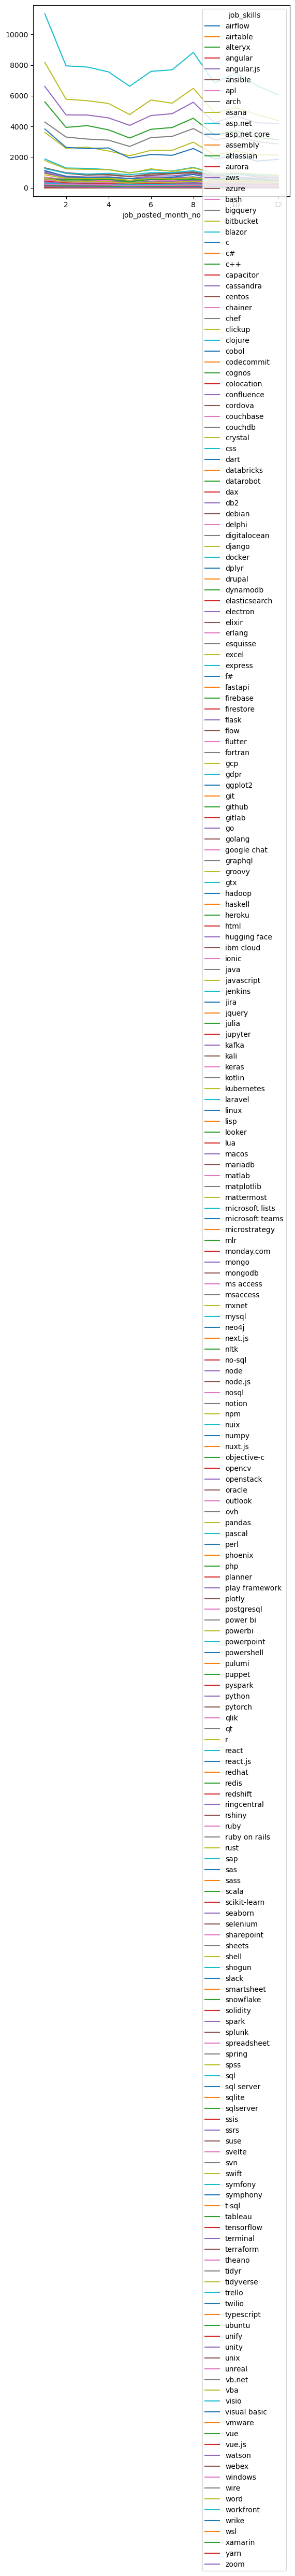

In [22]:
# Plotting the Pivot Table on a Line Chart
df_DA_pivot.plot(kind='line')

- Yeah... looks great!! We will have to Remove the Legend, but even that, we can see that there's just too many Skills appearing on here
- We should Filter down the Number of Skills being Displayed on the Visualization
    - Filter down by those that have the highest Count because currently, it's just Filtered Alphabetically
- So what we can do to Solve this is, Create a New Row in our Pivot Table called `Total` that Sums up all the Values inside the Pivot Table
    - We will Create a New Index Value
        - Start by declaring our DataFrame of `df_DA_pivot`
        - To do this, we need to use the `.loc` Method
        - Specifying that it's Called `['Total']`
        - This is Creating a New Row called **Total**
        - Then Set it Equal to the DataFrame `df_DA_pivot`
        - Then Running the `.sum()` Method on it

In [23]:
# Creating a New Row in the Pivot Table called `Total` that Sums up all the Values inside the Pivot Table
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

# Printing it out and Inspecting the New Total Column
df_DA_pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,asp.net core,assembly,atlassian,aurora,aws,azure,bash,bigquery,bitbucket,blazor,c,c#,c++,capacitor,cassandra,centos,chainer,chef,clickup,clojure,cobol,codecommit,cognos,colocation,confluence,cordova,couchbase,couchdb,crystal,css,...,suse,svelte,svn,swift,symfony,symphony,t-sql,tableau,tensorflow,terminal,terraform,theano,tidyr,tidyverse,trello,twilio,typescript,ubuntu,unify,unity,unix,unreal,vb.net,vba,visio,visual basic,vmware,vue,vue.js,watson,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,197,17,551,63,2,20,2,1,29,34,1,73,33,13,1077,1288,71,443,59,0,389,233,226,1,43,5,0,106,3,0,9,1,264,3,242,1,3,0,161,115,...,0,0,6,36,1,16,182,5596,76,77,26,0,5,11,14,7,14,4,19,33,203,1,19,839,298,121,17,103,4,31,17,228,6,1778,0,11,6,0,9,95
2,169,2,448,49,0,14,1,4,27,13,0,64,26,11,761,987,41,290,21,1,255,164,145,0,20,0,0,60,0,0,5,0,181,0,163,2,0,0,129,85,...,0,1,1,36,2,7,111,3936,47,62,20,0,0,4,9,3,6,1,9,23,100,2,9,625,224,113,12,132,1,10,9,202,6,1235,4,2,5,0,4,41
3,181,4,442,34,0,23,6,1,17,13,0,53,29,12,705,887,44,300,14,1,262,136,150,0,28,1,0,76,7,1,6,0,216,1,172,3,0,0,113,106,...,1,0,2,28,6,5,126,4051,45,62,29,0,3,5,8,4,8,1,17,24,113,2,10,595,205,112,12,88,2,16,8,194,8,1203,1,1,3,1,5,45
4,155,4,413,22,0,11,8,9,9,15,1,28,27,11,720,832,40,270,32,0,231,123,173,0,31,1,0,68,0,3,12,0,181,0,138,0,0,1,100,76,...,0,2,4,38,0,0,124,3776,65,61,19,0,0,6,6,0,8,1,21,19,90,3,12,617,186,106,14,80,2,11,9,185,14,1177,8,2,1,0,6,26
5,128,8,310,30,0,19,9,2,8,21,0,35,14,12,603,727,31,229,21,1,214,138,127,0,20,3,0,33,0,1,10,1,166,2,137,1,0,0,94,61,...,0,2,8,19,0,2,97,3245,43,50,22,0,0,4,11,1,4,9,29,18,58,1,15,497,196,73,5,57,0,5,11,122,3,957,3,4,0,0,7,18
6,164,14,393,29,0,14,9,4,16,16,0,46,29,10,770,915,59,289,30,0,222,146,119,0,25,5,0,54,2,0,11,2,174,3,159,8,6,0,109,100,...,0,1,5,29,5,3,99,3812,53,43,21,1,1,6,9,1,16,0,28,21,98,1,10,624,231,91,12,91,3,15,8,157,14,1237,6,6,0,0,11,34
7,207,4,366,15,0,8,5,8,19,12,0,42,34,19,778,949,46,256,28,0,239,121,138,0,33,2,0,40,1,0,10,1,196,0,162,2,0,0,107,87,...,0,2,4,19,0,5,154,3928,73,44,22,0,3,9,9,0,12,1,10,25,70,5,18,574,191,80,17,77,3,14,5,161,11,1069,0,3,0,0,6,38
8,197,3,413,21,0,12,10,3,13,12,3,46,33,28,924,1035,49,315,31,0,334,170,178,0,29,1,0,65,1,3,0,0,222,0,192,1,3,0,94,99,...,0,0,10,23,1,8,164,4533,73,44,17,0,0,7,13,1,12,5,22,36,105,1,7,670,227,84,19,57,1,14,9,184,11,1298,0,1,0,0,11,41
9,118,4,317,21,0,14,3,10,12,10,0,38,20,31,717,821,53,234,29,0,206,108,135,0,28,1,0,45,2,0,10,0,139,0,160,3,5,1,88,82,...,0,0,7,22,0,2,82,3446,50,26,21,2,0,4,5,4,8,1,9,24,77,3,7,471,149,83,17,44,2,4,4,150,8,945,0,1,0,0,5,25


- Now we can see, Displaying at the bottom of the Pivot Table, the Total Row
- Only thing left to do, is Sort these Columns specifically, by what's in the Total Row
    - Start by declaring our DataFrame of `df_DA_pivot`
    - Using the `.loc` Method, acessing the `['Total']` Row
    - Sorting the Values using using the `sort_values()` Method
    - Adding in `ascending=False` will make this Print in Descending Order
    - What we need to get back is the `job_skills` which are the Column Titles and from there, we can Sort the DataFrame, based on those Column Titles
    - To get the Column Titles back, just need to Run the `.index` Property
    - We get the Index Values Returned, which are inside of a List, of all the different Columns

In [27]:
# Sorting the Columns based on what's in the Total Row
df_DA_pivot.loc['Total'].sort_values(ascending=False).index

Index(['sql', 'excel', 'python', 'tableau', 'power bi', 'r', 'sas',
       'powerpoint', 'word', 'sap',
       ...
       'xamarin', 'mattermost', 'gtx', 'esquisse', 'chainer', 'capacitor',
       'nuxt.js', 'msaccess', 'ovh', 'suse'],
      dtype='str', name='job_skills', length=235)

- With this! We can Pass this to our Pivot using the Square Bracket Notation `[]`
    - This basically says, All these Values inside of here, Sort the Columns of the Pivot Table by this
    - We are just Sorting the Pivot Table based on what Column Total has the highest Value
    - So now, our Pivot Table, will have the Column at the Front, that has the Highest Total Value
- TO do this
    - Declare the DataFrame of `df_DA_pivot` and set it Equal to itself so it overrides itself
    - Add Square Brackets `[]`
    - Paste in what we did above, where we Sorted the Columns based on what's in the Total Row `df_DA_pivot.loc['Total'].sort_values(ascending=False).index`

In [31]:
# Sorting the Columns of the Pivot Table in Descending order based on the Values in the Total Row
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]

# Printing out the Pivot Table to Inspect our work
df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,azure,oracle,aws,sql server,go,flow,vba,looker,snowflake,qlik,java,spark,jira,spss,javascript,alteryx,hadoop,sharepoint,outlook,bigquery,dax,gcp,mysql,databricks,sheets,ssis,c,git,pandas,ssrs,...,nuix,firestore,heroku,colocation,svelte,mlr,ionic,react.js,objective-c,hugging face,asp.net core,play framework,clojure,theano,microsoft lists,sqlserver,lisp,qt,pascal,debian,codecommit,blazor,couchdb,kali,haskell,f#,next.js,pulumi,shogun,angular.js,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,1288,1304,1077,1130,1002,954,839,695,597,682,691,626,639,631,578,551,607,499,502,443,408,396,377,341,389,430,389,363,301,386,...,0,4,2,3,0,1,1,1,0,0,1,3,0,0,0,2,1,0,0,1,1,0,0,0,0,1,0,0,3,2,0,0,0,0,0,1,1,0,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,987,942,761,739,680,683,625,522,542,575,426,398,417,374,390,448,377,354,360,290,270,275,286,244,232,314,255,208,186,275,...,0,0,0,0,1,1,1,1,0,0,0,2,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,887,820,705,654,651,573,595,530,506,479,411,407,413,405,408,442,387,405,375,300,269,255,319,177,192,255,262,216,223,214,...,0,0,2,1,0,1,1,3,1,1,0,2,1,0,1,1,0,1,1,2,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,832,868,720,686,669,584,617,473,543,497,449,421,375,397,348,413,369,360,345,270,251,292,275,234,240,259,231,220,212,229,...,0,0,2,0,2,1,2,2,0,0,1,2,3,0,0,0,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,727,746,603,603,616,478,497,409,421,459,380,341,323,308,296,310,314,294,275,229,226,254,249,190,241,223,214,217,195,194,...,1,2,3,2,2,0,0,0,3,0,0,0,1,0,1,0,0,1,0,2,1,1,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,1,0,0
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,915,824,770,581,675,622,624,526,549,513,386,381,394,372,360,393,331,333,355,289,256,282,265,258,283,265,222,249,295,225,...,0,1,0,3,1,2,0,2,1,1,0,0,0,1,0,3,0,1,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,949,909,778,692,655,634,574,526,527,455,442,413,367,362,388,366,324,310,329,256,285,293,270,279,288,230,239,254,279,230,...,0,0,0,0,2,1,0,1,2,3,0,0,0,0,0,1,1,1,2,0,1,0,0,0,0,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,1035,990,924,868,713,710,670,554,596,483,475,501,496,439,474,413,358,405,387,315,332,294,267,351,320,292,334,291,285,281,...,0,3,1,0,0,2,0,2,0,1,3,1,3,0,1,1,3,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,821,738,717,600,541,531,471,505,473,396,336,372,370,371,362,317,318,294,320,234,296,251,241,259,242,190,206,210,231,181,...,3,1,0,0,0,0,0,0,2,0,0,0,0,2,2,0,3,0,2,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0


- We now get this back!
- Where all these different Columns are Sorted in the Order that they should be, with the Highest Total at the start and Lowest Total at the end
- Only thing left to do is to Drop the `Total` Row because all it's going to do is jack up the Plotting if it's left in there, and we don't need it anymore so we should Drop it...
    - Declare the DataFrame of `df_DA_pivot`
    - Set it Equals to itself `df_DA_pivot` so it overrides itself 
    - Invoke the `.drop()` Method
    - Passing in `'Total'` so we can then Drop the `Total` Row

In [32]:
# Dropping the Total Row
df_DA_pivot = df_DA_pivot.drop('Total')

# Printing out the Pivot to Inspect it and make sure the Row has been Dropped
df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,azure,oracle,aws,sql server,go,flow,vba,looker,snowflake,qlik,java,spark,jira,spss,javascript,alteryx,hadoop,sharepoint,outlook,bigquery,dax,gcp,mysql,databricks,sheets,ssis,c,git,pandas,ssrs,...,nuix,firestore,heroku,colocation,svelte,mlr,ionic,react.js,objective-c,hugging face,asp.net core,play framework,clojure,theano,microsoft lists,sqlserver,lisp,qt,pascal,debian,codecommit,blazor,couchdb,kali,haskell,f#,next.js,pulumi,shogun,angular.js,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,1288,1304,1077,1130,1002,954,839,695,597,682,691,626,639,631,578,551,607,499,502,443,408,396,377,341,389,430,389,363,301,386,...,0,4,2,3,0,1,1,1,0,0,1,3,0,0,0,2,1,0,0,1,1,0,0,0,0,1,0,0,3,2,0,0,0,0,0,1,1,0,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,987,942,761,739,680,683,625,522,542,575,426,398,417,374,390,448,377,354,360,290,270,275,286,244,232,314,255,208,186,275,...,0,0,0,0,1,1,1,1,0,0,0,2,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,887,820,705,654,651,573,595,530,506,479,411,407,413,405,408,442,387,405,375,300,269,255,319,177,192,255,262,216,223,214,...,0,0,2,1,0,1,1,3,1,1,0,2,1,0,1,1,0,1,1,2,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,832,868,720,686,669,584,617,473,543,497,449,421,375,397,348,413,369,360,345,270,251,292,275,234,240,259,231,220,212,229,...,0,0,2,0,2,1,2,2,0,0,1,2,3,0,0,0,0,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,727,746,603,603,616,478,497,409,421,459,380,341,323,308,296,310,314,294,275,229,226,254,249,190,241,223,214,217,195,194,...,1,2,3,2,2,0,0,0,3,0,0,0,1,0,1,0,0,1,0,2,1,1,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,1,0,0
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,915,824,770,581,675,622,624,526,549,513,386,381,394,372,360,393,331,333,355,289,256,282,265,258,283,265,222,249,295,225,...,0,1,0,3,1,2,0,2,1,1,0,0,0,1,0,3,0,1,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,949,909,778,692,655,634,574,526,527,455,442,413,367,362,388,366,324,310,329,256,285,293,270,279,288,230,239,254,279,230,...,0,0,0,0,2,1,0,1,2,3,0,0,0,0,0,1,1,1,2,0,1,0,0,0,0,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,1035,990,924,868,713,710,670,554,596,483,475,501,496,439,474,413,358,405,387,315,332,294,267,351,320,292,334,291,285,281,...,0,3,1,0,0,2,0,2,0,1,3,1,3,0,1,1,3,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,821,738,717,600,541,531,471,505,473,396,336,372,370,371,362,317,318,294,320,234,296,251,241,259,242,190,206,210,231,181,...,3,1,0,0,0,0,0,0,2,0,0,0,0,2,2,0,3,0,2,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0


- Now we have everything in the Pivot, all Sorted correctly and looking good
- The `Total` Row is now gone as well!
- Everything looks correct and we have what we want
- Very last thing to do is to, Plot this!
    - Declare our DataFrame of `df_DA_pivot`
    - Access what we want from the DataFrame using the `iloc` Method since everything is Sorted
    - After `.iloc` we use the Square Brackets `[]`
    - Need to Pass in the Rows first, want all the Rows in here so do to that, we will use the Colon `:`
    - Then, for the Columns, we want the first 5 Values (reason why we are using iloc so we don't have to call them out explicitly since we can do Index slicing on this) by doing `:5`
    - Then we plot is, using `.plot()`
    - Declaring the `kind='line`
- Just like with every Visualization we will need to clean it up as follows:
    - Set the Title: `plt.title('Top 5 Skills for Data Analysts per Month')`
    - Set the Y Label: `plt.ylabel('Count')`
    - Set the X Label: `plt.xlabel('')`
    - Set the Show: `plt.show()`

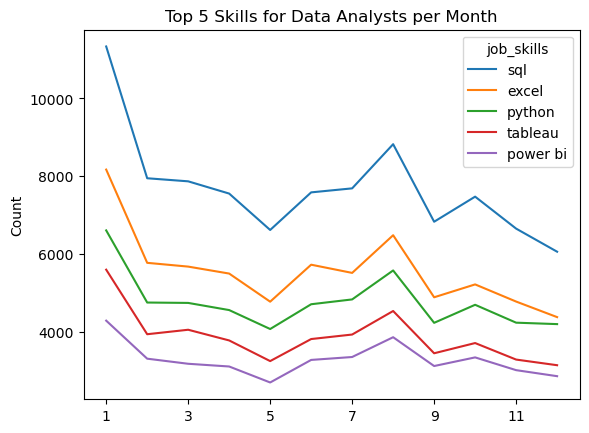

In [34]:
# Plotting the Visualization
df_DA_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

### Closing Remarks and Insights Learned
___
- We have very High Demand varying at the Beginning but that's explained because there's always a lot of Job Postings in January so that's why the Counts are above Normal
- A Count is all well and good, but it's better to Plot using a Percentage, since that's more representistic of Data
- Specifically when Plotting, What is the Percent of Job Postings with SQL? or What is the Percent of Job Postings with Excel?
    - Doing it this way, it's going to help clear up these Issues that we are seeing here of these abnormalities in Months like January and August